# 🌾 MODULE 2: TỰ ĐỘNG PHÂN ĐOẠN & BÓC TÁCH HẠT LÚA (SAHI + YOLO-SEG)
**Đề tài Nghiên cứu Khoa học**: Hệ thống thị giác máy tính và học sâu phục vụ ước lượng số lượng và đánh giá phẩm cấp hạt giống lúa.

### 🎯 Mục đích file này:
1. Nhận đường dẫn thư mục ảnh đầu vào (`INPUT_IMAGES_DIR`) và mô hình YOLO-seg (`MODEL_WEIGHTS_PATH`).
2. Sử dụng công nghệ **SAHI Sliced Prediction** cắt lát độ phân giải cao để phát hiện chính xác từng hạt lúa nhỏ.
3. Tự động bóc tách (crop) từng hạt lúa thành file ảnh PNG có **nền trong suốt (`RGBA`)**.
4. Xuất ảnh overlay trực quan (`_seg.jpg`) và lưu toàn bộ kết quả về các thư mục được chỉ định.


In [1]:
# Bước 1: Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Bước 2: Cài đặt thư viện SAHI và Ultralytics
!pip install ultralytics sahi opencv-python-headless matplotlib numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.8/151.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.0 MB/s eta 0:00:00


In [3]:
# Bước 3: Import thư viện
import os
import gc
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Bước 4: ⚙️ KHU VỰC CẤU HÌNH ĐƯỜNG DẪN ĐẦU VÀO / ĐẦU RA & THAM SỐ
# (Người dùng chỉ cần chỉnh sửa các biến trong cell này trước khi chạy)
# ─────────────────────────────────────────────────────────────────────────────
# 1. Đường dẫn file trọng số YOLO-seg đã huấn luyện (best.pt)
MODEL_WEIGHTS_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/35_special_images_segmentation.v1i.yolov8_v1_trained/weights/best.pt"

# 2. Đường dẫn folder chứa các ảnh gốc cần xử lý
INPUT_IMAGES_DIR   = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/TEST_IMAGES/DETECTABLE_TEST_IMAGES"

# 3. Đường dẫn folder đích để lưu các ảnh hạt lúa đã crop (PNG trong suốt RGBA)
OUTPUT_CROPPED_DIR = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DETECTED_OBJECTS/DATA1/OUTPUT_CROPPED_GRAINS"

# 4. Đường dẫn folder đích để lưu các ảnh tổng quan phủ màu mask (_seg.jpg)
OUTPUT_OVERLAY_DIR = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DETECTED_OBJECTS/DATA1/OUTPUT_OVERLAY_IMAGES"

# 5. Các tham số cắt lát SAHI
CONFIDENCE_THRESHOLD = 0.40   # Ngưỡng tin cậy (0.35 - 0.45)
SLICE_HEIGHT         = 512    # Chiều cao lát cắt (512 hoặc 640)
SLICE_WIDTH          = 512    # Chiều rộng lát cắt (512 hoặc 640)
OVERLAP_RATIO        = 0.25   # Tỷ lệ chồng lấn lát cắt (20% - 25%)
NMS_MATCH_THRESHOLD  = 0.65   # Ngưỡng khử trùng lặp NMS

print("=" * 60)
print(f"🎯 Model YOLO-seg      : {MODEL_WEIGHTS_PATH}")
print(f"📁 Folder ảnh đầu vào  : {INPUT_IMAGES_DIR}")
print(f"🌾 Folder lưu hạt crop : {OUTPUT_CROPPED_DIR}")
print(f"🖼️ Folder lưu overlay  : {OUTPUT_OVERLAY_DIR}")
print(f"⚙️ Tham số SAHI       : Slice={SLICE_WIDTH}x{SLICE_HEIGHT} | Overlap={OVERLAP_RATIO} | Conf={CONFIDENCE_THRESHOLD}")
print("=" * 60)


🎯 Model YOLO-seg      : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/35_special_images_segmentation.v1i.yolov8_v1_trained/weights/best.pt
📁 Folder ảnh đầu vào  : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/TEST_IMAGES/DETECTABLE_TEST_IMAGES
🌾 Folder lưu hạt crop : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DETECTED_OBJECTS/DATA1/OUTPUT_CROPPED_GRAINS
🖼️ Folder lưu overlay  : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DETECTED_OBJECTS/DATA1/OUTPUT_OVERLAY_IMAGES
⚙️ Tham số SAHI       : Slice=512x512 | Overlap=0.25 | Conf=0.4


In [6]:
# Bước 5: THỰC THI BÓC TÁCH HẠT LÚA TOÀN BỘ FOLDER
def run_grain_extraction_pipeline():
    if not os.path.exists(MODEL_WEIGHTS_PATH):
        raise FileNotFoundError(f"❌ Không tìm thấy file model tại: {MODEL_WEIGHTS_PATH}")
    if not os.path.exists(INPUT_IMAGES_DIR):
        raise FileNotFoundError(f"❌ Không tìm thấy folder ảnh đầu vào tại: {INPUT_IMAGES_DIR}")

    os.makedirs(OUTPUT_CROPPED_DIR, exist_ok=True)
    os.makedirs(OUTPUT_OVERLAY_DIR, exist_ok=True)

    # 1. Khởi tạo mô hình SAHI
    print("⏳ Đang nạp mô hình vào SAHI...")
    detection_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=MODEL_WEIGHTS_PATH,
        confidence_threshold=CONFIDENCE_THRESHOLD,
        device="cuda:0"
    )

    # 2. Lấy danh sách ảnh hợp lệ
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif')
    image_files = [f for f in os.listdir(INPUT_IMAGES_DIR) if f.lower().endswith(valid_exts)]
    print(f"🔍 Tìm thấy {len(image_files)} ảnh cần xử lý trong: {INPUT_IMAGES_DIR}")

    total_grains_cropped = 0

    # 3. Duyệt qua từng ảnh để cắt lát & bóc tách hạt
    for img_idx, img_name in enumerate(image_files, 1):
        img_path = os.path.join(INPUT_IMAGES_DIR, img_name)
        base_name = os.path.splitext(img_name)[0]
        print(f"[{img_idx}/{len(image_files)}] Đang xử lý: {img_name}...")

        # Dự đoán cắt lát SAHI
        result = get_sliced_prediction(
            img_path,
            detection_model,
            slice_height=SLICE_HEIGHT,
            slice_width=SLICE_WIDTH,
            overlap_height_ratio=OVERLAP_RATIO,
            overlap_width_ratio=OVERLAP_RATIO,
            postprocess_match_threshold=NMS_MATCH_THRESHOLD
        )

        predictions = result.object_prediction_list
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            print(f"  ⚠️ Không thể đọc ảnh: {img_path}")
            continue

        global_mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
        img_grain_count = 0

        for idx, obj in enumerate(predictions):
            if obj.mask is None or not obj.mask.segmentation:
                continue

            local_mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
            for polygon in obj.mask.segmentation:
                pts = np.array(polygon, np.int32).reshape((-1, 1, 2))
                cv2.fillPoly(local_mask, [pts], 255)
                cv2.fillPoly(global_mask, [pts], 255)

            ys, xs = np.where(local_mask == 255)
            if len(ys) > 0 and len(xs) > 0:
                y1, y2 = ys.min(), ys.max() + 1
                x1, x2 = xs.min(), xs.max() + 1

                crop_img  = img_bgr[y1:y2, x1:x2]
                crop_mask = local_mask[y1:y2, x1:x2]

                # Chuyển sang định dạng RGBA (Kênh 4 là mặt nạ độ trong suốt Alpha)
                rgba = cv2.cvtColor(crop_img, cv2.COLOR_BGR2BGRA)
                rgba[:, :, 3] = crop_mask

                # Lưu file hạt lúa sạch nền
                crop_filename = f"{base_name}_grain_{idx:04d}.png"
                cv2.imwrite(os.path.join(OUTPUT_CROPPED_DIR, crop_filename), rgba)
                img_grain_count += 1

        # Tạo ảnh phủ màu xanh overlay trực quan
        color_overlay = np.zeros_like(img_bgr, dtype=np.uint8)
        color_overlay[global_mask == 255] = [0, 255, 0]
        img_with_masks = cv2.addWeighted(color_overlay, 0.4, img_bgr, 1.0, 0)
        cv2.imwrite(os.path.join(OUTPUT_OVERLAY_DIR, f"{base_name}_seg.jpg"), img_with_masks)

        total_grains_cropped += img_grain_count
        print(f"  👉 Đã bóc tách thành công: {img_grain_count} hạt.")

        # Giải phóng bộ nhớ tránh tràn RAM/VRAM
        del result, predictions, img_bgr, global_mask, local_mask, color_overlay, img_with_masks
        gc.collect()

    print("" + "=" * 60)
    print(f"🎉 HOÀN THÀNH XỬ LÝ TOÀN BỘ FOLDER!")
    print(f"🌾 Tổng số hạt lúa đã bóc tách : {total_grains_cropped:,} hạt")
    print(f"📂 Thư mục lưu hạt sạch (RGBA) : {OUTPUT_CROPPED_DIR}")
    print(f"🖼️ Thư mục lưu ảnh trực quan   : {OUTPUT_OVERLAY_DIR}")
    print("=" * 60)

run_grain_extraction_pipeline()


⏳ Đang nạp mô hình vào SAHI...
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🔍 Tìm thấy 19 ảnh cần xử lý trong: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/TEST_IMAGES/DETECTABLE_TEST_IMAGES
[1/19] Đang xử lý: test18.jpg...
Performing prediction on 1 slices.
  👉 Đã bóc tách thành công: 23 hạt.
[2/19] Đang xử lý: test2.jpg...
Performing prediction on 1 slices.
  👉 Đã bóc tách thành công: 21 hạt.
[3/19] Đang xử lý: test3.jpg...
Performing prediction on 6 slices.
  👉 Đã bóc tách thành công: 28 hạt.
[4/19] Đang xử lý: test1.jpg...
Performing prediction on 9 slices.
  👉 Đã bóc tách thành công: 166 hạt.
[5/19] Đang xử lý: test4.jpg...
Performing prediction on 9 slices.
  👉 Đã bóc tách thành

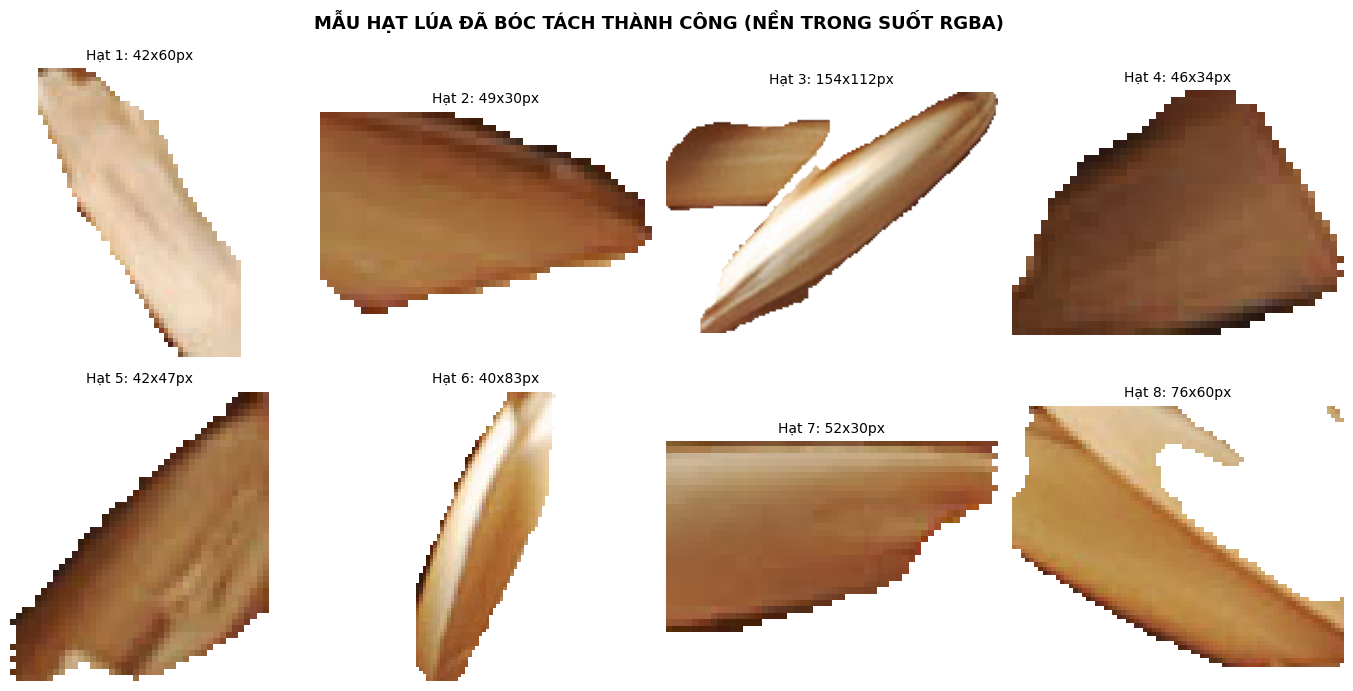

In [7]:
# Bước 6: Hiển thị Mẫu Trực Quan Các Hạt Lúa Đã Bóc Tách
cropped_files = [f for f in os.listdir(OUTPUT_CROPPED_DIR) if f.lower().endswith('.png')]

if len(cropped_files) > 0:
    sample_files = cropped_files[:min(8, len(cropped_files))]
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()

    for i, fname in enumerate(sample_files):
        fpath = os.path.join(OUTPUT_CROPPED_DIR, fname)
        img_bgra = cv2.imread(fpath, cv2.IMREAD_UNCHANGED)
        if img_bgra is not None:
            # Chuyển BGRA sang RGBA để hiển thị bằng matplotlib
            img_rgba = cv2.cvtColor(img_bgra, cv2.COLOR_BGRA2RGBA)
            axes[i].imshow(img_rgba)
            axes[i].set_title(f"Hạt {i+1}: {img_rgba.shape[1]}x{img_rgba.shape[0]}px", fontsize=10)
        axes[i].axis('off')

    plt.suptitle("MẪU HẠT LÚA ĐÃ BÓC TÁCH THÀNH CÔNG (NỀN TRONG SUỐT RGBA)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Chưa có ảnh hạt lúa nào trong thư mục đích.")


# ─────────────────────────────────────────────────────────────────────────────
# 🎯 BƯỚC BỔ SUNG: BÓC TÁCH HẠT LÚA CHO 1 ẢNH ĐƠN LẺ TÙY CHỌN (SINGLE IMAGE)
# ─────────────────────────────────────────────────────────────────────────────
Cell bên dưới cho phép bạn cắt hạt lúa cho **đúng 1 bức ảnh chỉ định** từ đường dẫn tự nhập (file trong Drive), tự động lưu kết quả vào thư mục chỉ định và hiển thị ảnh overlay + các hạt crop trực tiếp trên màn hình.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 🖼️ CẤU HÌNH & BÓC TÁCH CHO 1 ẢNH ĐƠN LẺ DUY NHẤT
# ─────────────────────────────────────────────────────────────────────────────
# 1. Nhập đường dẫn ảnh cần cắt (Thay đổi theo ý bạn)
CUSTOM_IMAGE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/TEST_IMAGES/DETECTABLE_TEST_IMAGES/test_sample.jpg"

# 2. Nhập đường dẫn thư mục muốn lưu các hạt crop của ảnh này
CUSTOM_OUTPUT_DIR = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DETECTED_OBJECTS/SINGLE_IMAGE_CROPPED"

# 3. Tham số tùy biến
CONF_THRESH   = 0.40   # Ngưỡng tin cậy
SLICE_SIZE    = 512    # Kích thước cắt lát (512x512)
OVERLAP       = 0.25   # Tỷ lệ chồng lấn lát cắt (25%)

def crop_single_image(image_path, output_dir, conf=0.4, slice_sz=512, overlap=0.25):
    if not os.path.exists(image_path):
        print(f"❌ Không tìm thấy file ảnh tại: {image_path}")
        return

    os.makedirs(output_dir, exist_ok=True)
    base_name = os.path.splitext(os.path.basename(image_path))[0]

    # 1. Nạp model nếu chưa có trong bộ nhớ
    global detection_model
    if 'detection_model' not in globals() or detection_model is None:
        print("⏳ Đang nạp mô hình SAHI...")
        detection_model = AutoDetectionModel.from_pretrained(
            model_type="ultralytics",
            model_path=MODEL_WEIGHTS_PATH,
            confidence_threshold=conf,
            device="cuda:0"
        )

    print(f"🚀 Đang phân đoạn và bóc tách ảnh: {os.path.basename(image_path)}...")

    # 2. Cắt lát dự đoán bằng SAHI
    result = get_sliced_prediction(
        image_path,
        detection_model,
        slice_height=slice_sz,
        slice_width=slice_sz,
        overlap_height_ratio=overlap,
        overlap_width_ratio=overlap,
        postprocess_match_threshold=0.65
    )

    predictions = result.object_prediction_list
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"❌ Không thể đọc nội dung ảnh: {image_path}")
        return

    global_mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
    saved_crops = []

    # 3. Duyệt và bóc tách từng hạt lúa
    for idx, obj in enumerate(predictions):
        if obj.mask is None or not obj.mask.segmentation:
            continue

        local_mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
        for polygon in obj.mask.segmentation:
            pts = np.array(polygon, np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(local_mask, [pts], 255)
            cv2.fillPoly(global_mask, [pts], 255)

        ys, xs = np.where(local_mask == 255)
        if len(ys) > 0 and len(xs) > 0:
            y1, y2 = ys.min(), ys.max() + 1
            x1, x2 = xs.min(), xs.max() + 1

            crop_img  = img_bgr[y1:y2, x1:x2]
            crop_mask = local_mask[y1:y2, x1:x2]

            # Chuyển sang định dạng RGBA 4 kênh (Nền trong suốt)
            rgba = cv2.cvtColor(crop_img, cv2.COLOR_BGR2BGRA)
            rgba[:, :, 3] = crop_mask

            crop_path = os.path.join(output_dir, f"{base_name}_grain_{idx:04d}.png")
            cv2.imwrite(crop_path, rgba)
            saved_crops.append(rgba)

    # 4. Lưu ảnh overlay trực quan tổng thể
    color_overlay = np.zeros_like(img_bgr, dtype=np.uint8)
    color_overlay[global_mask == 255] = [0, 255, 0]
    img_overlay = cv2.addWeighted(color_overlay, 0.4, img_bgr, 1.0, 0)
    overlay_path = os.path.join(output_dir, f"{base_name}_overlay_result.jpg")
    cv2.imwrite(overlay_path, img_overlay)

    print("=" * 60)
    print(f"✅ ĐÃ BÓC TÁCH XONG ẢNH: {os.path.basename(image_path)}")
    print(f"🌾 Tổng số hạt lúa tìm thấy: {len(saved_crops)} hạt")
    print(f"📂 Thư mục lưu hạt crop    : {output_dir}")
    print(f"🖼️ Ảnh overlay trực quan   : {overlay_path}")
    print("=" * 60)

    # 5. Hiển thị kết quả trực tiếp trong Colab
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Kết quả SAHI: Tìm thấy {len(saved_crops)} hạt lúa", fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.show()

    # Hiển thị 8 hạt mẫu đầu tiên
    if len(saved_crops) > 0:
        num_show = min(8, len(saved_crops))
        fig, axes = plt.subplots(2, 4, figsize=(14, 6))
        axes = axes.flatten()
        for i in range(num_show):
            axes[i].imshow(cv2.cvtColor(saved_crops[i], cv2.COLOR_BGRA2RGBA))
            axes[i].set_title(f"Hạt {i+1}", fontsize=10)
            axes[i].axis('off')
        for j in range(num_show, len(axes)):
            axes[j].axis('off')
        plt.suptitle("MẪU CÁC HẠT LÚA ĐÃ BÓC TÁCH (NỀN TRONG SUỐT)", fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# GỌI HÀM BÓC TÁCH CHO ẢNH ĐƠN LẺ
# ─────────────────────────────────────────────────────────────────────────────
crop_single_image(
    image_path=CUSTOM_IMAGE_PATH,
    output_dir=CUSTOM_OUTPUT_DIR,
    conf=CONF_THRESH,
    slice_sz=SLICE_SIZE,
    overlap=OVERLAP
)
